# Machine-Learning Classification of Control and HCV Samples

This notebook demonstrates a reproducible machine-learning workflow for classifying control and HCV-infected samples using simulated host gene-expression data.

The dataset is entirely dummy and does not contain patient data or unpublished research results. The purpose is to demonstrate the computational workflow, validation strategy, and interpretation of model performance.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import average_precision_score, balanced_accuracy_score, make_scorer, matthews_corrcoef, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from pathlib import Path
import joblib

## Simulate host gene-expression data

As this project is purely for demonstration, so simulated gene expression data is created. Small HCV-associated signal and study to study variation is added instead of completely random expression data

In [2]:
random_seed = 42
rng = np.random.default_rng(random_seed)

n_studies = 4
samples_per_study = 30
n_genes = 20
n_samples = n_studies * samples_per_study

# Create study labels
study = np.repeat(
    [f"Study_{i+1}" for i in range(n_studies)],
    samples_per_study
)

# Create condition labels
condition = np.tile(
    ["Control"] * (samples_per_study // 2) + ["HCV"] * (samples_per_study // 2),
    n_studies
)

# Generate initial gene expression matrix
expression = rng.normal(0, 1, size=(n_samples, n_genes))

hcv_samples = condition == "HCV"

# add artificial hcv-associated signal
expression[hcv_samples, :5] += 0.8 

# generate study specific differences
study_effect = rng.normal(0, 0.3, size=(n_studies, n_genes))

expression+= np.repeat(study_effect, samples_per_study, axis=0)

# Add approximately 1% missing values
expression[rng.random(expression.shape) < 0.01] = np.nan

# Create generic gene names
gene_names = [f"Gene_{i + 1:02d}" for i in range(n_genes)]

data = pd.DataFrame(expression, columns=gene_names)
data.insert(0, "Condition", condition)
data.insert(0, "Study", study)

print("Data shape:" , data.shape)
data.head()

Data shape: (120, 22)


,Study,Condition,Gene_01,Gene_02,Gene_03,Gene_04,Gene_05,Gene_06,Gene_07,Gene_08,...,Gene_11,Gene_12,Gene_13,Gene_14,Gene_15,Gene_16,Gene_17,Gene_18,Gene_19,Gene_20
0,Study_1,Control,0.170896,-0.745927,0.834803,0.731298,-2.210817,-1.796428,0.215060,-0.422619,...,0.609088,1.250495,-0.444803,0.694836,0.800500,-0.452264,0.145256,-1.148508,1.063321,-0.748056
1,Study_1,Control,-0.318683,-0.386872,1.306893,-0.363797,-0.688110,-0.846382,0.619529,0.259068,...,1.871337,0.066288,-1.023076,-1.246178,0.948970,1.536001,-0.337442,-1.029782,-0.639611,-0.047537
2,Study_1,Control,0.609433,0.837212,-0.581158,0.022894,-0.143096,-0.275560,0.958649,0.117219,...,NaN,1.103992,-1.967989,-0.752076,-0.137382,-0.231849,-0.498637,1.305316,-0.680960,0.270148
3,Study_1,Control,-1.816691,-0.040828,0.247105,0.376955,0.451445,0.299098,-0.261505,-0.568728,...,-1.545997,-0.660584,-1.430286,0.064756,0.475417,1.097514,-0.650748,-0.031086,0.810461,-1.007476
4,Study_1,Control,0.322954,-0.367869,-0.278702,-0.591005,-1.455622,-0.007276,-0.382182,-0.093882,...,0.395075,0.374218,-0.934132,-0.512123,-1.354344,-1.040084,-1.546194,-1.186873,0.584645,-1.603609


In [3]:
# Check the simulated expression data

print(pd.crosstab(data["Study"], data["Condition"]))
print(f"Missing values: {data.isna().sum().sum()}")

Condition  Control  HCV
Study                  
Study_1         15   15
Study_2         15   15
Study_3         15   15
Study_4         15   15
Missing values: 23


# ML model architecture

In [4]:
# Create ML input

X = data[gene_names]
y = data["Condition"].map({
    "Control": 0,
    "HCV": 1
})

groups = data["Study"]

print("Expression data:", X.shape)
print("Condition labels:", y.shape)
print("Number of studies:", groups.nunique())

Expression data: (120, 20)
Condition labels: (120,)
Number of studies: 4


In [5]:
# Build ML model pipeline

pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")), #imputer handles missing values
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear")) #default c=1.0
])

In [6]:
# Repeated stratified cross-validation

cv_stratified = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_seed
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "mcc": make_scorer(matthews_corrcoef),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_scores = cross_validate(
    pipeline,
    X,
    y,
    cv=cv_stratified,
    scoring=scoring
)

cv_results = pd.DataFrame({
    "Balanced accuracy": cv_scores["test_balanced_accuracy"],
    "MCC": cv_scores["test_mcc"],
    "ROC-AUC": cv_scores["test_roc_auc"],
    "Average precision": cv_scores["test_average_precision"]
})

cv_results.agg(["mean", "std"]).round(3)

,Balanced accuracy,MCC,ROC-AUC,Average precision
mean,0.698,0.402,0.805,0.823
std,0.077,0.155,0.072,0.066


## Leave-one-study-out validation

Evaluation of the model whether the model could generalise to a study that was not used during training. Each study was held out once while the model was trained on the remaining three studies.

In [7]:
loso = LeaveOneGroupOut()

loso_scores = cross_validate(
    pipeline,
    X,
    y,
    groups=groups,
    cv=loso,
    scoring=scoring
)

loso_results = pd.DataFrame({
    "Held-out study": np.unique(groups),
    "Balanced_accuracy": loso_scores["test_balanced_accuracy"],
    "MCC": loso_scores["test_mcc"],
    "ROC_AUC": loso_scores["test_roc_auc"],
    "Average_precision": loso_scores["test_average_precision"]
})

loso_results.round(3)

,Held-out study,Balanced_accuracy,MCC,ROC_AUC,Average_precision
0,Study_1,0.733,0.509,0.849,0.867
1,Study_2,0.833,0.680,0.844,0.754
2,Study_3,0.667,0.364,0.724,0.718
3,Study_4,0.700,0.452,0.773,0.820


## Save results and final model

After completing cross-validation, pipeline is fiited using the complete simulated dataset and saved it with the evaluation tables. This final fitted model is provided only to demonstrate model persistence and is not an independently validated biological model.

In [8]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

cv_results.to_csv(output_dir / "repeated_cv_results.csv", index=False)
loso_results.to_csv(output_dir / "loso_results.csv", index=False)

pipeline.fit(X, y)

joblib.dump(
    pipeline,
    output_dir / "simulated_svm_pipeline.joblib"
)

print("Results and model saved in:", output_dir)

Results and model saved in: outputs


## Inspect the SVM feature weights

Because the SVM uses a linear kernel, its fitted feature weights are examined. Positive weights favour the HCV class, while negative weights favour the Control class. The absolute weight is used to rank the strength of each feature's contribution.

In [9]:
svm_weights = pd.DataFrame({
    "Gene": gene_names,
    "Weight": pipeline.named_steps["svm"].coef_[0]
})

svm_weights["Absolute weight"] = svm_weights["Weight"].abs()

svm_weights = (
    svm_weights
    .sort_values("Absolute weight", ascending=False)
    .reset_index(drop=True)
)

svm_weights.to_csv(output_dir / "svm_feature_weights.csv", index=False)
svm_weights.head(10)

,Gene,Weight,Absolute weight
0,Gene_04,0.892569,0.892569
1,Gene_01,0.792437,0.792437
2,Gene_02,0.781927,0.781927
3,Gene_05,0.675975,0.675975
4,Gene_11,-0.640695,0.640695
5,Gene_13,0.561606,0.561606
6,Gene_03,0.535030,0.535030
7,Gene_14,0.396349,0.396349
8,Gene_15,0.338869,0.338869
9,Gene_09,0.297019,0.297019


### Highest-ranked feature weights

All five features containing the simulated HCV-associated signal appeared among the seven highest-ranked features. Other features may also receive substantial weights because of random variation and study effects.

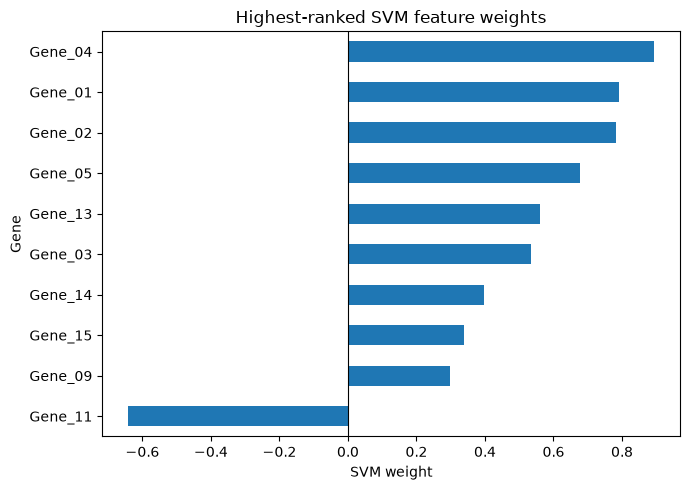

In [10]:
top_weights = (
    svm_weights
    .head(10)
    .sort_values("Weight")
)

top_weights.plot(
    x="Gene",
    y="Weight",
    kind="barh",
    figsize=(7, 5),
    legend=False
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("SVM weight")
plt.ylabel("Gene")
plt.title("Highest-ranked SVM feature weights")
plt.tight_layout()

plt.savefig(
    output_dir / "svm_feature_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

All five features containing the simulated HCV-associated signal appeared among the seven highest-ranked features. However, several features without an inserted signal also received substantial weights, demonstrating why model coefficients should not be interpreted as biological evidence without further validation.

## Visualise model performance

The distributions below show how model performance varied across the 25 repeated cross-validation splits.

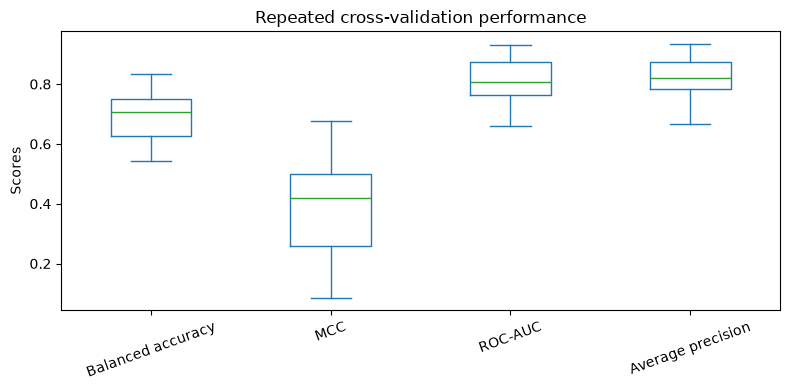

In [11]:
# Repeated cross-validation performance visualisation

cv_results.plot(
    kind="box",
    figsize=(8, 4)
)

plt.ylabel("Scores")
plt.title("Repeated cross-validation performance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    output_dir / "repeated_cv_results.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Interpretation and limitations

The linear SVM detected the simulated difference between Control and HCV-labelled samples. Across repeated cross-validation splits, the model achieved a mean balanced accuracy of 0.698, MCC of 0.402, ROC-AUC of 0.805, and average precision of 0.823.

Leave-one-study-out performance varied among the four simulated studies. This illustrates why testing on a completely unseen study can provide a more demanding assessment of model generalisation than randomly dividing pooled samples.

These results are only a demonstration of the analysis workflow. The expression values, study effects, feature names, and condition-associated signal were simulated and should not be interpreted as biological evidence or model performance on real HCV samples.